<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/FashionMNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
#!pip install wandb -qU

# FashionMNIST CNN
This notebook demonstrates how to build and track a CNN using PyTorch and WandB.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import wandb

# Login to WandB
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zhiruihu33 (zhirui-dl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### 1. Define the CNN Model
We use a sequence of `Conv2d` -> `BatchNorm2d` -> `ReLU` -> `MaxPool2d` blocks.

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # Block 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # a border of zero-valued pixels is added around the input image before the convolution.
            # allows the filter to center on the edge pixels
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Block 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

### 2. Training Loop with WandB Visualization

In [ ]:
from torch.utils.data import random_split
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def train(epochs=50, patience=5):
    # Initialize WandB run
    wandb.init(project="fashion_mnist_experiment", name="CNN", config={
        "learning_rate": 0.0001,
        "epochs": epochs,
        "batch_size": 64,
        "architecture": "CNN",
        "patience": patience
    })
    config = wandb.config

    # Setup Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    full_train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

    train_size = 50000
    val_size = 10000
    train_subset, val_subset = random_split(full_train_set, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=config.batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FashionCNN().to(device)

    # Print model architecture and parameters
    print(model)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal Trainable Parameters: {total_params:,}")
    wandb.config.update({"total_parameters": total_params})

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

    # Early Stopping Initialization
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    # Training
    for epoch in range(config.epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / val_size

        wandb.log({"train/loss": avg_train_loss, "val/loss": avg_val_loss, "val/accuracy": val_acc, "epoch": epoch})
        print(f"Epoch [{epoch+1}/{config.epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config.patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

    print("Training finished.")
    return model, device

### 3. Testing with with WandB Visualization

In [ ]:
def test(model, device):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    print(f"Final Test Accuracy: {test_acc:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_set.classes, yticklabels=test_set.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    # Log to WandB
    wandb.log({"test_accuracy": test_acc, "confusion_matrix": wandb.Image(plt)})
    plt.show()
    wandb.finish()

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.26MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.79MB/s]


FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total Trainable Parameters: 421,834
Epoch [1/50], Train Loss: 0.4791, Val Loss: 0.3485, Val Acc: 0.88%
Epoch [2/50], Train Loss: 0.3070, Val Loss: 0.2950, Val Acc: 0.90%
Epoch [3/50], Train Loss: 0.2657, Val Loss: 0.2761, Val Acc: 0.90%
Epoch [4/50], Train Loss

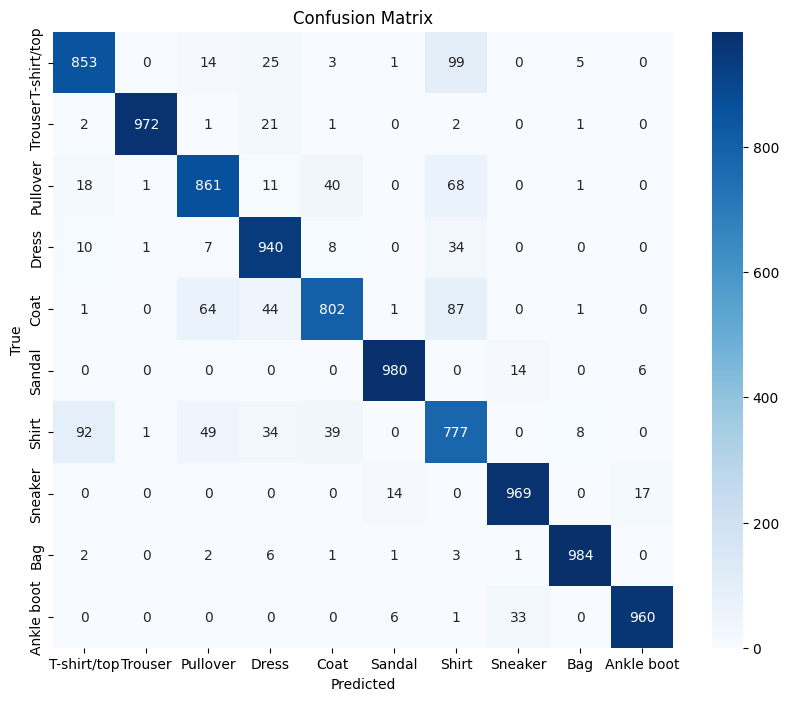

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
test_accuracy,▁
train/loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁
val/accuracy,▁▄▅▆▆▇▆██▆▇███
val/loss,█▅▄▃▃▂▃▁▁▃▃▁▂▂
epoch,13
test_accuracy,90.98
train/loss,0.11884
val/accuracy,0.9152
val/loss,0.24528


In [ ]:
# Execute
trained_model, device = train(epochs=50, patience=5)
test(trained_model, device)